In [19]:
#Extração do CSV

import pandas as pd

df = pd.read_csv("academia_redfit.csv")

df.head()


,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária


In [20]:
#Informação do DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   object 
 2   frequencia_semanal_treino  949 non-null    float64
 3   tipo_atividade             1000 non-null   object 
 4   tempo_medio_exercicio      954 non-null    float64
 5   minutos_totais_semana      905 non-null    float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   object 
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   object 
 11  estado                     1000 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 93.9+ KB


In [21]:
#Preencher campos nulos com média

df.fillna({
    'frequencia_semanal_treino': df['frequencia_semanal_treino'].mean(),
    'tempo_medio_exercicio': df['tempo_medio_exercicio'].mean(),
    'minutos_totais_semana': df['minutos_totais_semana'].mean()
}, inplace=True)

In [22]:
# Padronizar sexo
df['sexo'] = df['sexo'].str.lower().str.strip()

# Padronizar estado
df['estado'] = df['estado'].str.lower().str.strip()

# Padronizar tipo de atividade
df['tipo_atividade'] = df['tipo_atividade'].str.lower().str.strip()


df.head()

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,outro,7.0,natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,ativa
1,30,outro,7.0,yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,ativa
2,35,masculino,5.0,cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,ativa
3,43,outro,3.0,yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,ativa
4,37,masculino,0.0,crossfit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,sedentária


In [23]:
#Converter data_matricula para o formato de DATE

df['data_matricula'] = pd.to_datetime(df['data_matricula'])

In [24]:
df['evolucao_pgc'] = df['primeiro_PGC'] - df['ultimo_PGC']

df['tempo_cliente'] = (pd.Timestamp.today() - df['data_matricula']).dt.days

#O IMC estimado não foi calculado, pois o conjunto de dados não possui as variáveis necessárias (peso e altura).

In [25]:
df.head()

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado,evolucao_pgc,tempo_cliente
0,48,outro,7.0,natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,ativa,14.6,1697
1,30,outro,7.0,yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,ativa,1.7,1909
2,35,masculino,5.0,cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,ativa,15.8,1483
3,43,outro,3.0,yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,ativa,-4.8,1206
4,37,masculino,0.0,crossfit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,sedentária,3.4,791


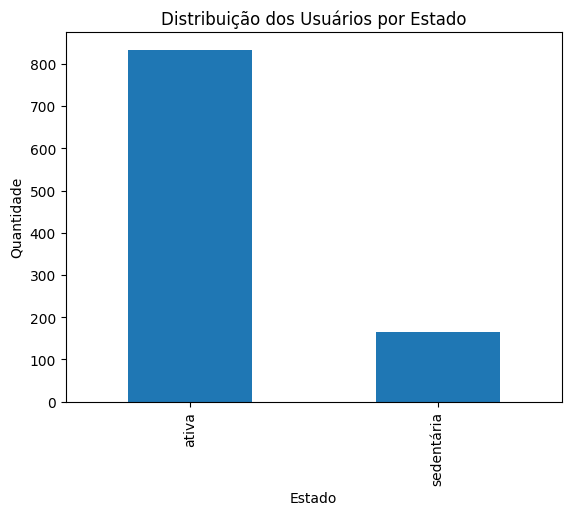

In [26]:
import matplotlib.pyplot as plt

df['estado'].value_counts().plot(kind='bar')
plt.title("Distribuição dos Usuários por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade")
plt.show()

In [27]:
df['tipo_atividade'].unique()

array(['natação', 'yoga', 'cardio', 'crossfit', 'musculação', 'futebol',
       'natacao', 'soccer', 'fut', 'swimming'], dtype=object)

In [28]:
df['tipo_atividade'] = df['tipo_atividade'].replace({

    'natacao': 'natação',
    'natação': 'natação',
    'swimming': 'natação',

    'futebol': 'futebol',
    'fut': 'futebol',
    'soccer': 'futebol',

    'yoga': 'yoga',
    'cardio': 'cardio',
    'crossfit': 'crossfit',
    'musculação': 'musculação',
    'musculacao': 'musculação'
})

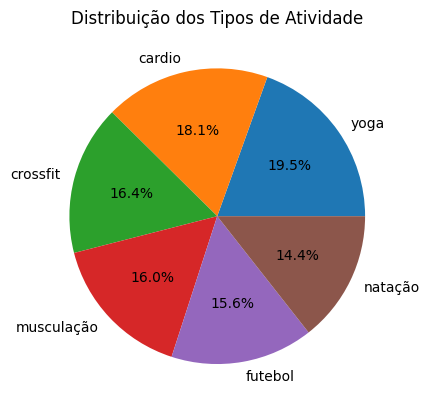

In [29]:
df['tipo_atividade'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribuição dos Tipos de Atividade")
plt.ylabel("")
plt.show()

In [30]:
import numpy as np

df['estado'] = np.where(df['frequencia_semanal_treino'] >= 5, 'atleta', df['estado'])

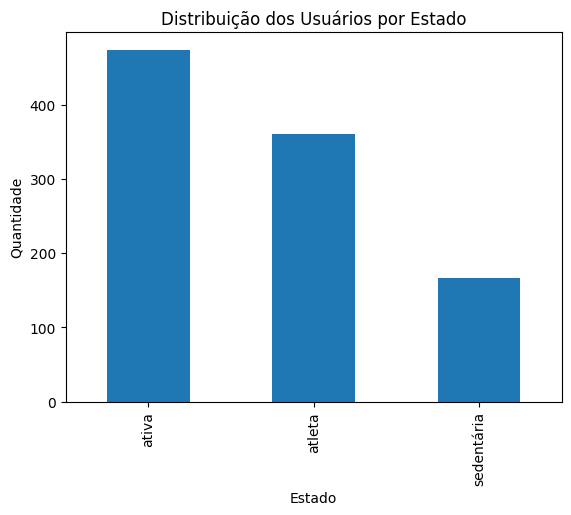

In [31]:
df['estado'].value_counts().plot(kind='bar')
plt.title("Distribuição dos Usuários por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade")
plt.show()

In [33]:
df_powerbi = df.copy()
df_powerbi['preco_plano'] = df_powerbi['preco_plano'].round(2)
df_powerbi.to_csv("academia_tratado.csv", index=False)
print("CSV para Power BI salvo com sucesso!")

CSV para Power BI salvo com sucesso!


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['sexo', 'tipo_atividade', 'possui_nutricionista', 'estado']:
    df[col] = le.fit_transform(df[col])

In [16]:
X = df[['idade',
        'tempo_medio_exercicio',
        'minutos_totais_semana',
        'preco_plano',
        'evolucao_pgc',
        'tempo_cliente']]

y = df['estado']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9
